# 05 — Persistent Homology

We now have the basic TDA pipeline

$$
\text{metric spaces}
\longrightarrow
\text{simplicial complexes}
\longrightarrow
\text{homology}
\longrightarrow
\text{filtrations}.
$$

Homology studies holes in one complex. A filtration gives a nested family

$$
K_0\subseteq K_1\subseteq\cdots\subseteq K_m.
$$

**Persistent homology** tracks how homological features evolve through this family.

We will develop the ideas geometrically first, then compute and visualize simple examples.

## Learning goals

By the end of this notebook, you should be able to:

1. explain birth and death of homology classes;
2. describe a class by an interval $[b,d)$;
3. interpret persistence and barcodes;
4. interpret persistence diagrams;
5. understand persistent Betti numbers;
6. connect Vietoris–Rips filtrations to persistence diagrams;
7. distinguish the mathematical output from its scientific interpretation.

Our recurring philosophy is:

> **Definition → example → non-example → computation → visualization → exercise.**

## 1. From homology to persistent homology

A filtration

$$
K_0\subseteq K_1\subseteq\cdots\subseteq K_m
$$

induces maps

$$
H_k(K_0)\longrightarrow H_k(K_1)\longrightarrow\cdots\longrightarrow H_k(K_m).
$$

Thus persistent homology asks not only how many holes exist at one scale, but which homological features survive as the scale changes.

## 2. Birth and death

Suppose a homology class first appears at parameter $b$. We say it is **born** at $b$.

If it becomes trivial at parameter $d$, we say it **dies** at $d$.

Its persistence interval is

$$
[b,d).
$$

Its lifetime is

$$
d-b.
$$

For example,

$$
[2,5)
$$

has persistence

$$
5-2=3.
$$

### Example: a loop

Imagine

$$
\text{vertices}
\longrightarrow
\text{edges}
\longrightarrow
\text{loop}
\longrightarrow
\text{filled loop}.
$$

The 1-dimensional hole is born when the cycle is completed and dies when the cycle becomes a boundary.

If this happens at $b=2$ and $d=3$, the class contributes

$$
[2,3).
$$

### Non-example: an ordinary Betti number

Knowing only that

$$
\beta_1(K_2)=1
$$

does not tell us when the class was born or when it will die.

Persistent homology contains information across the filtration, not merely a snapshot at one parameter.

## 3. A complete small example

Consider a triangle filtration:

| $t$ | complex | $\beta_0$ | $\beta_1$ |
|---:|---|---:|---:|
| 0 | three isolated vertices | 3 | 0 |
| 1 | two edges | 1 | 0 |
| 2 | three boundary edges | 1 | 1 |
| 3 | filled triangle | 1 | 0 |

The 1-dimensional class is born at $2$ and dies at $3$.

Therefore its persistence interval is

$$
[2,3)
$$

and its persistence is

$$
3-2=1.
$$

## 4. Visualizing birth and death

### Pseudocode

```text
Create three vertices.

At t = 0:
    draw the vertices.

At t = 1:
    add two edges.

At t = 2:
    add the third edge.
    A loop is present.

At t = 3:
    fill the triangle.
    The loop disappears.
```

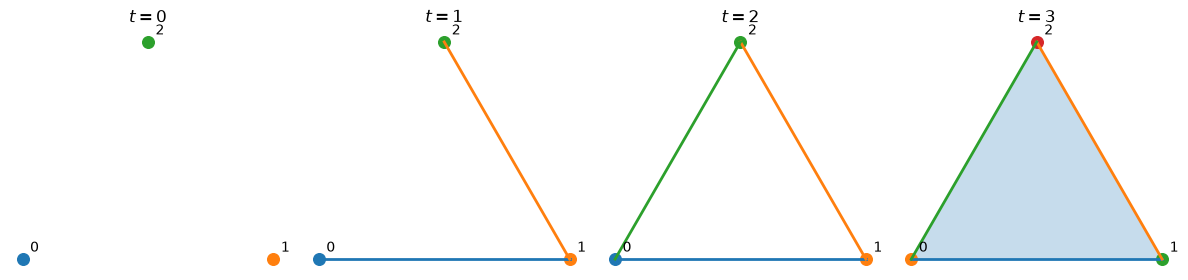

In [1]:
import matplotlib.pyplot as plt

pts = {0:(0,0), 1:(1,0), 2:(0.5,0.866)}
stages = [
    [],
    [(0,1),(1,2)],
    [(0,1),(1,2),(0,2)],
    [(0,1),(1,2),(0,2)]
]

fig, axes = plt.subplots(1, 4, figsize=(12,3))

for t, (ax, edges) in enumerate(zip(axes, stages)):
    if t == 3:
        ax.fill([0,1,0.5], [0,0,0.866], alpha=0.25)

    for u,v in edges:
        ax.plot([pts[u][0],pts[v][0]],
                [pts[u][1],pts[v][1]], linewidth=2)

    for v,(x,y) in pts.items():
        ax.scatter(x,y,s=70)
        ax.text(x+0.03,y+0.03,str(v))

    ax.set_title(f"$t={t}$")
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()

The loop exists only between the birth and death parameters.

This is the geometric meaning of the interval

$$
[2,3).
$$

## 5. Persistence

For a finite interval

$$
[b,d),
$$

the persistence is

$$
\operatorname{pers}=d-b.
$$

Thus

$$
[1,4)
$$

has persistence $3$, while

$$
[2,3)
$$

has persistence $1$.

Persistence measures the range of filtration scales over which a class survives.

### Important interpretation

A long-lived feature is not automatically a scientifically meaningful feature.

Persistence tells us **how long a homological class survives in the chosen filtration**.

Interpreting that feature requires us to consider the data, the metric, the filtration, noise, and the scientific question.

## 6. Barcodes

A **barcode** represents every persistence interval by a horizontal bar.

For example,

$$
[1,4),\qquad [2,3),\qquad [5,8)
$$

become three horizontal bars.

### Pseudocode

```text
For every interval [birth, death):
    draw a horizontal segment from birth to death.
```

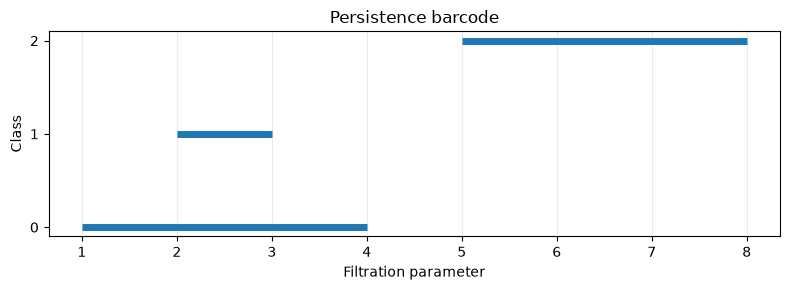

In [2]:
intervals = [(1,4), (2,3), (5,8)]

fig, ax = plt.subplots(figsize=(8,3))

for row, (birth, death) in enumerate(intervals):
    ax.hlines(row, birth, death, linewidth=5)

ax.set_xlabel("Filtration parameter")
ax.set_ylabel("Class")
ax.set_title("Persistence barcode")
ax.set_yticks(range(len(intervals)))
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

The bar length is exactly the persistence:

$$
d-b.
$$

A barcode therefore gives an immediate visual summary of birth, death, and lifetime.

## 7. Persistence diagrams

We can encode the same interval

$$
[b,d)
$$

as a point

$$
(b,d)
$$

in the birth-death plane.

The diagonal is

$$
d=b.
$$

The distance in the vertical direction from $(b,d)$ to the diagonal is proportional to

$$
d-b,
$$

the persistence.

Thus points close to the diagonal represent short-lived classes, while points farther from it have larger persistence.

### Pseudocode

```text
Draw the birth-death plane.
Draw the diagonal d = b.
For each interval [b,d):
    plot the point (b,d).
```

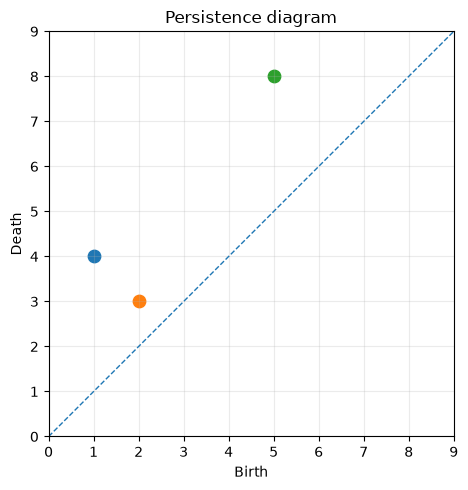

In [3]:
diagram = [(1,4), (2,3), (5,8)]

fig, ax = plt.subplots(figsize=(5,5))

m = 9
ax.plot([0,m], [0,m], linestyle="--", linewidth=1)

for birth, death in diagram:
    ax.scatter(birth, death, s=80)

ax.set_xlabel("Birth")
ax.set_ylabel("Death")
ax.set_title("Persistence diagram")
ax.set_xlim(0,m)
ax.set_ylim(0,m)
ax.set_aspect("equal")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 8. Barcode and diagram are two views of the same information

For finite intervals,

$$
[b,d)
\quad\longleftrightarrow\quad
(b,d).
$$

So

$$
\boxed{\text{barcode}}
\qquad\Longleftrightarrow\qquad
\boxed{\text{persistence diagram}}.
$$

The barcode emphasizes lifetimes. The diagram emphasizes the geometry of birth and death.

## 9. The persistence module

For a fixed dimension $k$, a filtration gives

$$
H_k(K_0)\longrightarrow H_k(K_1)\longrightarrow\cdots\longrightarrow H_k(K_m).
$$

This sequence is called a **persistence module**.

A simple class may behave schematically like

$$
0\longrightarrow\mathbb F_2
\longrightarrow\mathbb F_2
\longrightarrow0.
$$

It is absent before birth, present while alive, and absent after death.

The interval notation records this behavior compactly.

## 10. Persistent Betti numbers

Ordinary homology gives

$$
\beta_k(K_t)=\dim H_k(K_t).
$$

For $s\leq t$, the inclusion induces

$$
H_k(K_s)\longrightarrow H_k(K_t).
$$

The persistent Betti number is

$$
\beta_k^{s,t}
=
\dim\operatorname{im}
\left(
H_k(K_s)\to H_k(K_t)
\right).
$$

It counts classes that are represented at scale $s$ and remain represented at scale $t$.

Ordinary Betti numbers are therefore snapshots; persistent Betti numbers encode survival across a range of scales.

## 11. Dimension zero and connected components

Persistent homology also tracks connected components.

Suppose three isolated points gradually become connected by two edges.

Initially,

$$
\beta_0=3.
$$

After the first edge, two components merge, so

$$
\beta_0=2.
$$

After the second edge,

$$
\beta_0=1.
$$

The corresponding $H_0$ persistence intervals record when components are born and when they merge.

This is one reason dimension-zero persistence is closely related to clustering and single-linkage structure.

## 12. Essential classes

A class may survive throughout the entire filtration.

Its interval can be written

$$
[b,\infty).
$$

Such a class has no finite death parameter within the filtration.

For example, if a final complex is connected, one connected-component class usually persists to the end:

$$
[0,\infty).
$$

Infinite intervals require special treatment in persistence diagrams because they do not correspond to finite points $(b,d)$.

## 13. A small computational representation

For learning purposes, persistence intervals can simply be stored as pairs.

### Pseudocode

```text
Input intervals (birth, death).

For each interval:
    compute death - birth.

Return the persistence values.
```

In [4]:
def persistence_lengths(intervals):
    return [death - birth for birth, death in intervals]

intervals = [(2,3), (1,4), (5,8)]
print(persistence_lengths(intervals))

[1, 3, 3]


This elementary representation is intentional.

Later, Ripser and GUDHI will compute persistence information for actual filtered complexes. Understanding intervals first makes the output of those libraries much easier to interpret.

## 14. From a point cloud to persistent homology

For a finite metric space $X$, the Vietoris–Rips complex at scale $\varepsilon$ is

$$
\operatorname{VR}(X,\varepsilon)
=
\left\{
\sigma\subseteq X:
d(p,q)\leq\varepsilon
\text{ for all }p,q\in\sigma
\right\}.
$$

If

$$
\varepsilon_1\leq\varepsilon_2,
$$

then

$$
\operatorname{VR}(X,\varepsilon_1)
\subseteq
\operatorname{VR}(X,\varepsilon_2).
$$

Thus we obtain a filtration

$$
\operatorname{VR}(X,\varepsilon_1)
\subseteq
\operatorname{VR}(X,\varepsilon_2)
\subseteq\cdots.
$$

The full pipeline is

$$
\boxed{\text{point cloud}}
\longrightarrow
\boxed{\text{metric}}
\longrightarrow
\boxed{\text{Vietoris--Rips filtration}}
\longrightarrow
\boxed{\text{persistent homology}}
\longrightarrow
\boxed{\text{persistence diagram}}.
$$

## 15. Circle point cloud: seeing the topology

A point cloud sampled from a circle is a useful example.

At small scales, nearby points are disconnected.

At intermediate scales, edges connect around the circle and a 1-dimensional loop can appear.

At sufficiently large scales, higher-dimensional simplices can fill the loop.

We therefore expect a nontrivial $H_1$ feature over an intermediate range of scales.

### Pseudocode

```text
Sample points around a circle.

Compute all pairwise distances.

For several epsilon values:
    draw an edge when distance <= epsilon
    display the resulting 1-skeleton

Compare the stages.
```

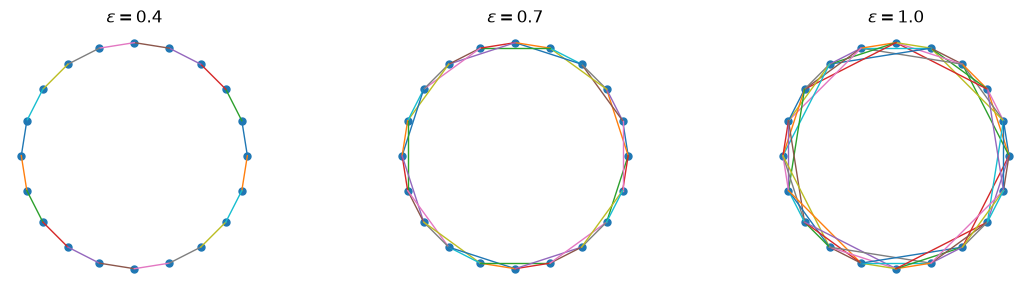

In [5]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 20, endpoint=False)
circle = np.column_stack([np.cos(theta), np.sin(theta)])

D = np.linalg.norm(
    circle[:, None, :] - circle[None, :, :],
    axis=2
)

scales = [0.4, 0.7, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(12,3))

for ax, eps in zip(axes, scales):
    for i in range(len(circle)):
        for j in range(i+1, len(circle)):
            if D[i,j] <= eps:
                ax.plot(
                    [circle[i,0], circle[j,0]],
                    [circle[i,1], circle[j,1]],
                    linewidth=1
                )

    ax.scatter(circle[:,0], circle[:,1], s=25)
    ax.set_title(rf"$\varepsilon={eps}$")
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()

The picture shows only the **1-skeleton**.

The full Vietoris–Rips complex contains higher-dimensional simplices as well. Those higher-dimensional simplices are essential for determining when an $H_1$ class dies.

This is an important distinction between visualizing a filtration and computing its persistent homology.

## 16. A conceptual comparison

Ordinary homology asks:

$$
\boxed{\text{What holes does }K\text{ have?}}
$$

Persistent homology asks:

$$
\boxed{\text{How do the holes of }K_t\text{ evolve as }t\text{ changes?}}
$$

Thus:

$$
\text{homology}
\quad\longrightarrow\quad
\text{topology at one scale},
$$

while

$$
\text{persistent homology}
\quad\longrightarrow\quad
\text{topology across scales}.
$$

## 17. What persistence diagrams do and do not tell us

A persistence diagram records:

- birth;
- death;
- persistence.

It does not by itself determine:

- the cause of a feature;
- whether a feature is scientifically meaningful;
- whether a particular metric is appropriate;
- whether a particular filtration is appropriate.

Those are additional modeling and scientific questions.

Persistent homology is a mathematical summary of the chosen filtered data.

## 18. Connection to the previous notebooks

The development is now:

### Notebook 01 — Metric spaces

$$
d(x,y)
$$

gives a notion of distance.

### Notebook 02 — Simplicial complexes

We construct spaces from vertices, edges, triangles, and higher simplices.

### Notebook 03 — Homology

We compute

$$
H_k(K)
$$

and Betti numbers

$$
\beta_k.
$$

### Notebook 04 — Filtrations

We construct

$$
K_0\subseteq K_1\subseteq\cdots\subseteq K_m.
$$

### Notebook 05 — Persistent homology

We track

$$
H_k(K_0)\to H_k(K_1)\to\cdots\to H_k(K_m)
$$

and summarize the resulting classes by intervals, barcodes, and persistence diagrams.

## 19. Summary

The central ideas are:

1. A filtration gives a sequence of nested complexes.
2. Homology classes can be born and die.
3. A finite-lived class is represented by

   $$
   [b,d).
   $$

4. Its persistence is

   $$
   d-b.
   $$

5. A collection of intervals can be displayed as a barcode.
6. The same intervals can be displayed as a persistence diagram.
7. Persistent Betti numbers measure survival between two scales.
8. Infinite intervals represent classes with no finite death in the filtration.
9. Vietoris–Rips filtrations provide a fundamental route from point clouds to persistent homology.

The next step is to understand how persistence is **computed algorithmically** from a filtered simplicial complex.

## Exercises

### Exercise 1 — Birth and death

A class is born at

$$
b=3
$$

and dies at

$$
d=7.
$$

Write its persistence interval and persistence.

### Exercise 2 — Barcode

Consider

$$
[1,6),\qquad [2,4),\qquad [5,9).
$$

Draw the barcode and compute the persistence of each class.

### Exercise 3 — Persistence diagram

Plot the points corresponding to

$$
[1,6),\qquad [2,4),\qquad [5,9).
$$

What does distance from the diagonal measure?

### Exercise 4 — Betti numbers versus persistence

Can two different homology classes contribute to the same value of $\beta_1$ at different scales?

Explain why a sequence of Betti numbers alone does not identify the history of individual classes.

### Exercise 5 — Dimension zero

Three isolated points are connected by two edges, one at a time.

Describe the evolution of $\beta_0$ and sketch the corresponding $H_0$ persistence intervals.

### Exercise 6 — Infinite persistence

Interpret the interval

$$
[2,\infty).
$$

How would you display it in a barcode?

### Exercise 7 — Circle

Why should a point cloud sampled from a circle have a persistent $H_1$ feature over some intermediate range of scales?

### Exercise 8 — Critical thinking

Suppose two datasets have similar-looking persistence diagrams.

List at least three additional questions you would ask before concluding that the datasets have similar scientific structure.

## References

1. H. Edelsbrunner and J. Harer, *Computational Topology: An Introduction*, American Mathematical Society, 2010.

2. G. Carlsson, “Topology and Data,” *Bulletin of the American Mathematical Society* 46 (2009), 255–308.

3. F. Chazal and B. Michel, “An Introduction to Topological Data Analysis: Fundamental and Practical Aspects for Data Scientists,” *Frontiers in Artificial Intelligence* 4 (2021), 667963.

   DOI: https://doi.org/10.3389/frai.2021.667963

4. R. Ghrist, “Barcodes: The Persistent Topology of Data,” *Bulletin of the American Mathematical Society* 45 (2008), 61–75.